In [ ]:
#bibliothéques

import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
print(" Bibliothèques importées ")

 Bibliothèques importées 


In [ ]:
%pip install statsmodels -q
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline

In [ ]:
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
print(f"{df.shape[0]} lignes × {df.shape[1]} colonnes")


Le dataset contient : 4372 lignes et 52 colonnes
Nom des colonnes :
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'C

In [ ]:
# ============================================================
# CELLULE 3 : Premier aperçu
# ============================================================

print("=== 5 premières lignes ===")
display(df.head())

print("\n=== 5 dernières lignes ===")
display(df.tail())

print("\n=== Aperçu aléatoire de 5 lignes ===")
display(df.sample(5, random_state=42))

=== 5 premières lignes ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1



=== 5 dernières lignes ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
4367,13436,2,1,196.89,16.407500,4.698021,10.20,25.50,76,6.333333,...,UK,Nouveau,Faible,Inconnu,Moyen,Modéré,M,Active,United Kingdom,0
4368,15520,2,1,343.50,19.083333,7.451560,9.48,34.68,314,17.444444,...,UK,Nouveau,Faible,Inconnu,Grand,Modéré,M,Active,United Kingdom,0
4369,13298,1,1,360.00,180.000000,127.279221,90.00,270.00,96,48.000000,...,UK,Nouveau,Faible,Inconnu,Grand,Spécialisé,F,Closed,United Kingdom,0
4370,14569,1,1,227.39,18.949167,35.731358,1.65,122.40,79,6.583333,...,UK,Nouveau,Faible,Inconnu,Moyen,Modéré,F,Active,United Kingdom,0
4371,12713,1,1,848.55,22.330263,14.375260,5.04,71.70,508,13.368421,...,Europe continentale,Nouveau,Faible,Inconnu,Moyen,Explorateur,F,Active,Germany,0



=== Aperçu aléatoire de 5 lignes ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
2014,14633,266,1,344.90,17.245000,3.752434,10.20,27.0,96,4.800000,...,UK,Nouveau,Critique,Inconnu,Petit,Explorateur,F,Active,United Kingdom,1
457,13050,9,28,5684.61,13.470640,9.611339,-19.90,79.6,3707,8.784360,...,UK,Établi,Faible,Semaine,Moyen,Explorateur,Unknown,Active,United Kingdom,0
478,17975,15,14,4393.61,14.793300,23.312296,-95.20,98.1,1552,5.225589,...,UK,Établi,Faible,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
438,12347,2,7,4310.00,23.681319,23.289902,5.04,249.6,2458,13.505495,...,Europe du Nord,Ancien,Faible,Inconnu,Moyen,Explorateur,Unknown,Active,Iceland,0
3728,12420,64,1,600.39,20.703103,9.201862,10.08,39.8,345,11.896552,...,Europe du Sud,Nouveau,Élevé,Inconnu,Moyen,Explorateur,M,Active,Cyprus,0


In [ ]:
print("=== Types de données de chaque colonne ===")
df.info()

=== Types de données de chaque colonne ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  First

In [ ]:
# ============================================================
# CELLULE 5 : Statistiques descriptives
# ============================================================

print("=== Statistiques des colonnes NUMÉRIQUES ===")
display(df.describe())

# describe() vous donne pour chaque colonne numérique :
# count   = nombre de valeurs (sans les NaN)
# mean    = moyenne
# std     = écart-type (dispersion)
# min/max = valeurs extrêmes
# 25%/50%/75% = quartiles

print("\n=== Statistiques des colonnes CATÉGORIELLES ===")
display(df.describe(include='object'))

=== Statistiques des colonnes NUMÉRIQUES ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,3061.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1898.459701,28.839013,88.672383,-86.425754,185.179522,1122.344007,22.389288,...,0.009149,2.036825,0.032045,93.053294,5.075480,19.883969,49.149951,21.778591,5.328225,0.332571
std,1722.390705,100.765435,9.338754,8219.345141,127.323926,2689.001161,2876.398935,2881.283699,4672.790720,213.257466,...,0.126218,7.340449,0.107003,232.471608,9.338754,18.512016,18.267835,139.267307,15.410883,0.471188
min,12346.000000,1.000000,1.000000,-4287.630000,-4287.630000,0.000000,-168469.600000,-4287.630000,-303.000000,-144.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,18.000000,-1.000000,-1.000000,0.000000
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,...,0.000000,0.000000,0.000000,17.000000,1.000000,8.000000,34.000000,1.000000,2.000000,0.000000
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,...,0.000000,0.000000,0.000000,42.000000,3.000000,14.600000,49.000000,2.000000,3.000000,0.000000
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,...,0.000000,1.000000,0.021009,102.000000,5.000000,25.212500,65.000000,3.000000,4.000000,1.000000
max,18287.000000,374.000000,248.000000,279489.020000,3861.000000,137554.852393,3861.000000,168469.600000,196719.000000,12540.000000,...,4.000000,226.000000,1.000000,7983.000000,248.000000,219.000000,80.000000,999.000000,99.000000,1.000000



=== Statistiques des colonnes CATÉGORIELLES ===


,RegistrationDate,NewsletterSubscribed,LastLoginIP,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country
count,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372,4372
unique,1700,1,4372,4,7,4,5,4,4,13,4,4,3,3,3,3,4,37
top,12/10/2010,Yes,59.252.219.201,Potentiels,Inconnu,High,Occasionnel,Automne,Matin,UK,Nouveau,Faible,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom
freq,11,4372,1,1589,1311,1664,1198,1768,1471,3959,1714,1695,3125,2414,3018,1649,3944,3950


=== Colonnes avec des valeurs manquantes ===


,Valeurs manquantes,Pourcentage (%)
Age,1311,29.99
AvgDaysBetweenPurchases,79,1.81


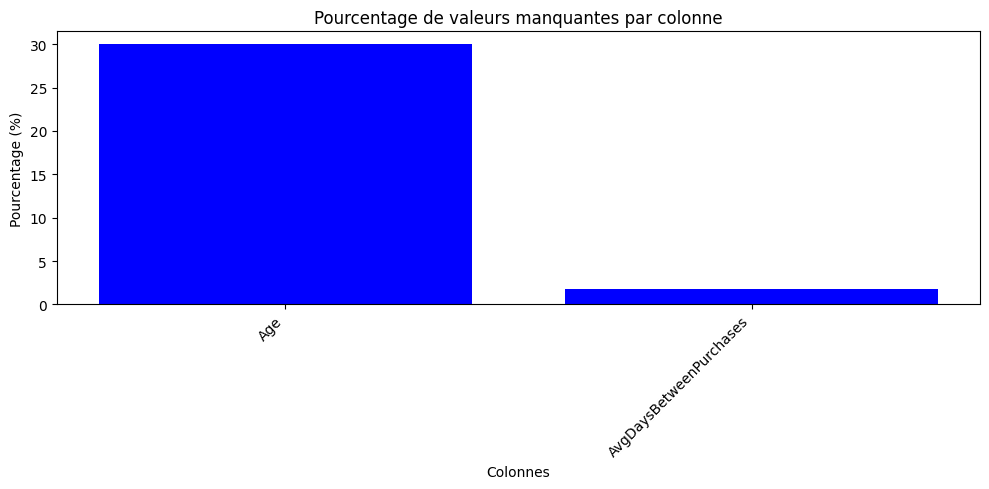

✅ Graphique sauvegardé dans reports/


In [ ]:
# ============================================================
# CELLULE 6 : Valeurs manquantes (NaN)
# ============================================================

# Compter les valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
pourcentage = (df.isnull().sum() / len(df)) * 100

# Créer un tableau récapitulatif
resume_nan = pd.DataFrame({
    'Valeurs manquantes': valeurs_manquantes,
    'Pourcentage (%)': pourcentage.round(2)
})

# Afficher seulement les colonnes qui ont des NaN
resume_nan = resume_nan[resume_nan['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

print("=== Colonnes avec des valeurs manquantes ===")
display(resume_nan)

# Visualisation graphique
plt.figure(figsize=(10, 5))
plt.bar(resume_nan.index, resume_nan['Pourcentage (%)'], color='blue')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/valeurs_manquantes.png')  # Sauvegarder le graphique
plt.show()
print(" Graphique sauvegardé dans reports/")

In [ ]:
manquantes_pct = (df.isnull().sum() / len(df) * 100).round(2)
resume_nan = pd.DataFrame({'Manquantes': df.isnull().sum(), 'Pourcentage %': manquantes_pct})
resume_nan = resume_nan[resume_nan['Manquantes'] > 0].sort_values('Pourcentage %', ascending=False)

cols_50 = resume_nan[resume_nan['Pourcentage %'] > 50]
print("⚠️ Colonnes >50% manquantes :", "Aucune" if len(cols_50) == 0 else "")
if len(cols_50) > 0:
    print(cols_50)


In [ ]:
# ============================================================
# CELLULE 7 : Doublons
# ============================================================

nb_doublons = df.duplicated().sum()
print(f"🔍 Nombre de lignes dupliquées : {nb_doublons}")

if nb_doublons > 0:
    print("sont les doublons :")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("no doublons détectés !")

🔍 Nombre de lignes dupliquées : 0
✅ Aucun doublon détecté !


=== SupportTicketsCount ===
SupportTicketsCount
-1.0        43
 0.0       596
 1.0      1140
 2.0      1183
 3.0       753
 4.0       365
 5.0       141
 6.0        41
 7.0        17
 8.0         3
 9.0         3
 999.0      87
Name: count, dtype: int64

=== SatisfactionScore ===
SatisfactionScore
-1.0     115
 0.0     120
 1.0     824
 2.0     777
 3.0     789
 4.0     786
 5.0     847
 99.0    114
Name: count, dtype: int64


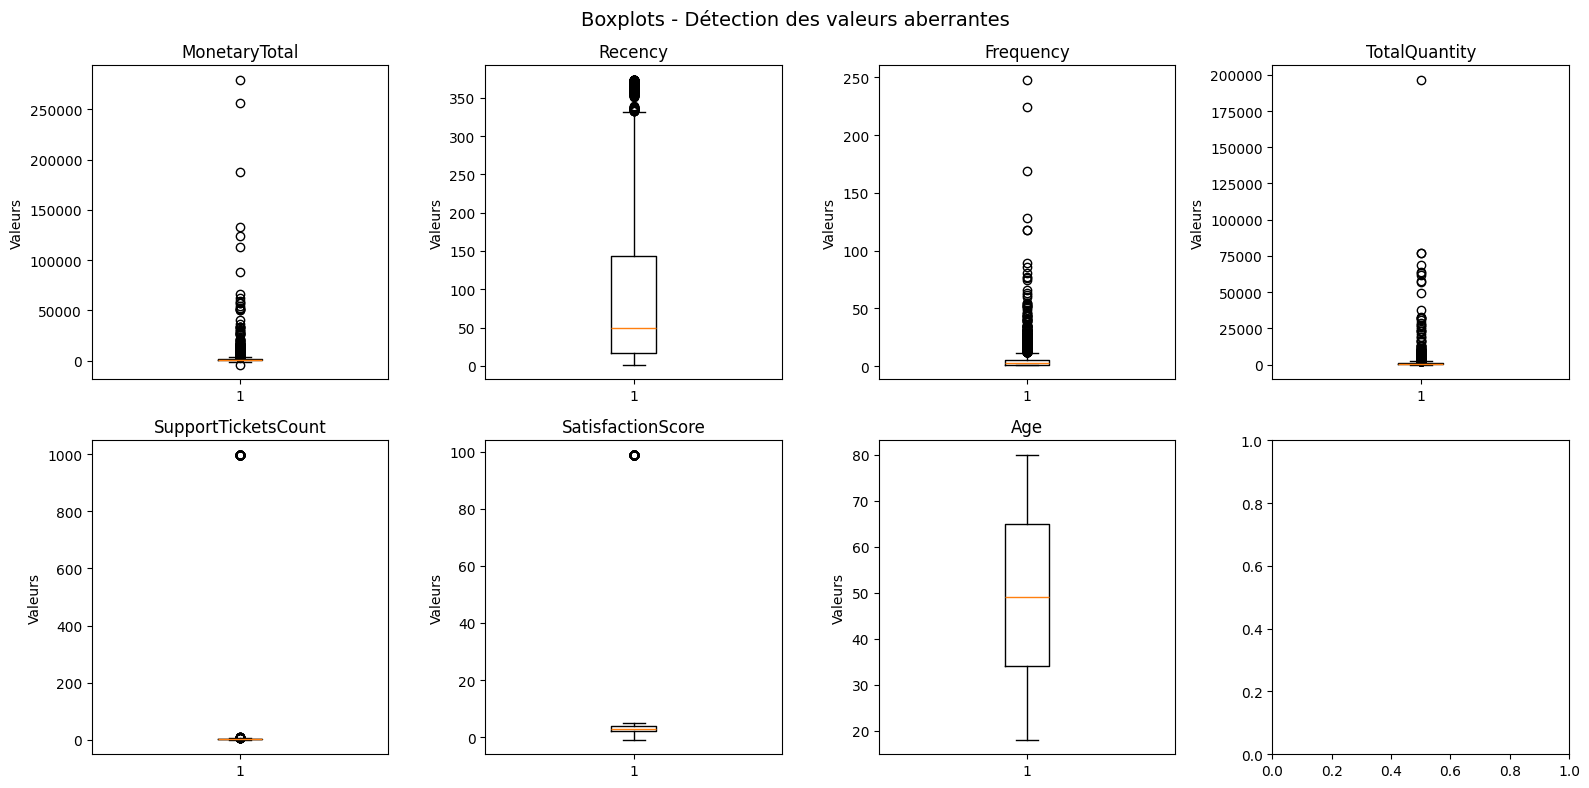

✅ Graphique sauvegardé dans reports/


In [ ]:
# ============================================================
# CELLULE 8 : Valeurs aberrantes (outliers)/juste visualisation en utilisant IQR  on peut utiliser isolation forest pour faire ca automatiquement
# ============================================================

print("=== SupportTicketsCount ===")
print(df['SupportTicketsCount'].value_counts().sort_index())

print("\n=== SatisfactionScore ===")
print(df['SatisfactionScore'].value_counts().sort_index())

# Visualisation boxplot pour voir les outliers
colonnes_numeriques = [
    'MonetaryTotal', 'Recency', 'Frequency', 
    'TotalQuantity', 'SupportTicketsCount', 
    'SatisfactionScore', 'Age'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(colonnes_numeriques):
    if col in df.columns:
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(col)
        axes[i].set_ylabel('Valeurs')

plt.suptitle('Boxplots - Détection des valeurs aberrantes', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/boxplots_outliers.png')
plt.show()

print("Graphique sauvegardé dans reports/")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['SupportTicketsCount'].hist(bins=50, ax=axes[0])
axes[0].set_title('SupportTicketsCount')
axes[0].set_xlabel('Tickets'); axes[0].set_ylabel('Clients')
df['SatisfactionScore'].hist(bins=50, ax=axes[1])
axes[1].set_title('SatisfactionScore')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Clients')
plt.tight_layout(); plt.show()


=== Distribution du Churn ===
Churn
0    2918
1    1454
Name: count, dtype: int64

Pourcentage de clients partis : 33.26%


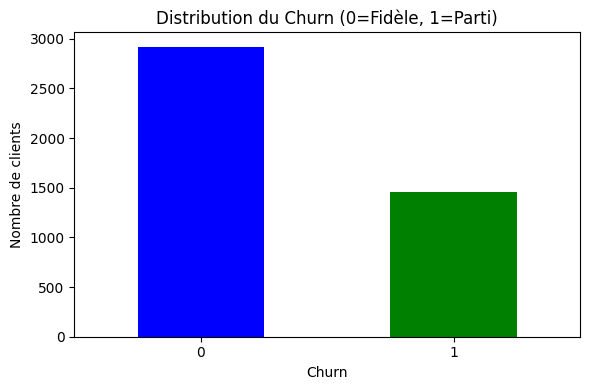

In [ ]:
# ============================================================
# CELLULE 9 : Distribution de la variable cible CHURN
# ============================================================

# Churn = 0 signifie client fidèle, Churn = 1 = client parti
print("=== Distribution du Churn ===")
print(df['Churn'].value_counts())
print(f"\nPourcentage de clients partis : {df['Churn'].mean()*100:.2f}%")

# Graphique
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['blue', 'green'])
plt.title('Distribution du Churn (0=Fidèle, 1=Parti)')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/distribution_churn.png')
plt.show()

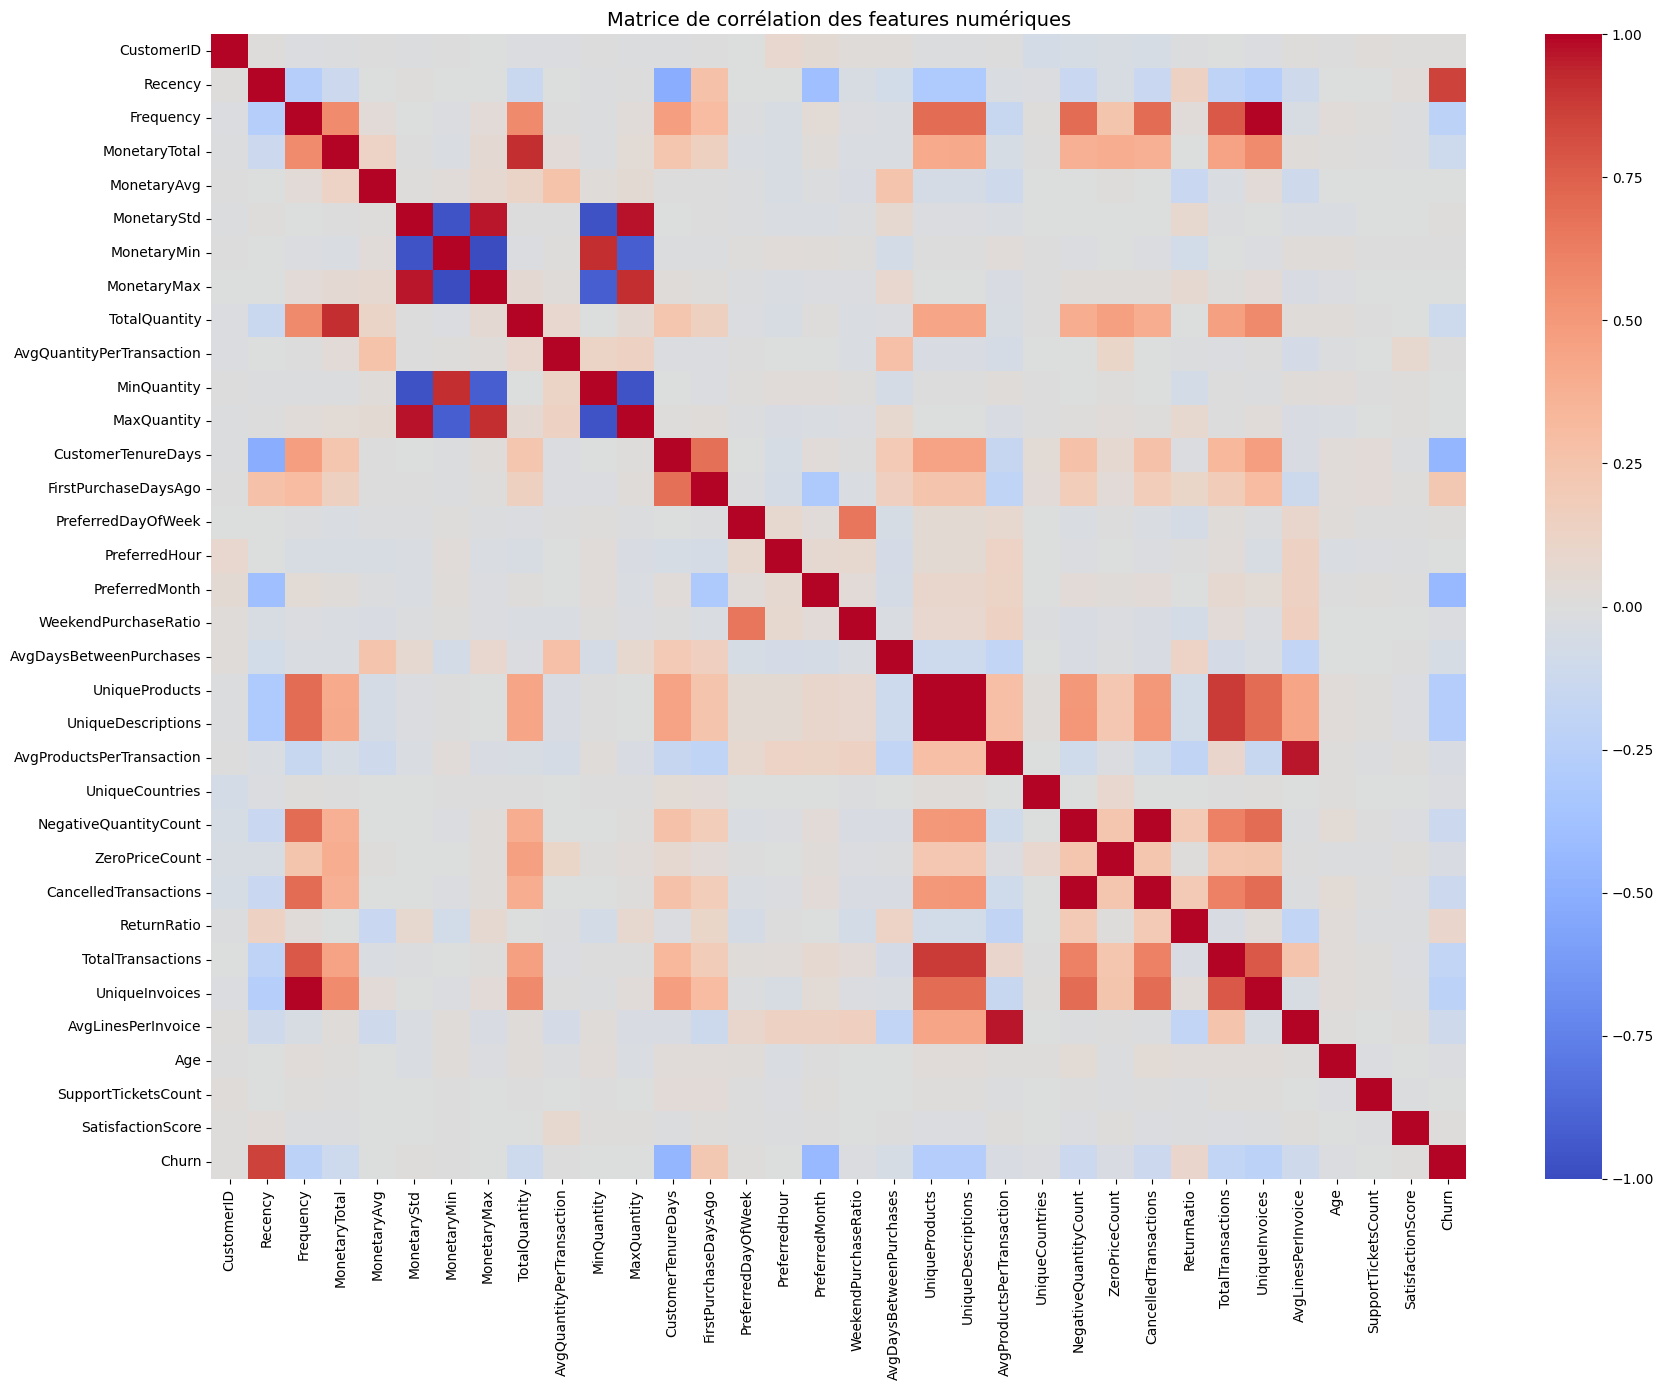

=== Paires de features très corrélées (|corr| > 0.8) ===


,Feature 1,Feature 2,Corrélation
17,NegativeQuantityCount,CancelledTransactions,1.000
1,Frequency,UniqueInvoices,1.000
13,UniqueProducts,UniqueDescriptions,1.000
6,MonetaryStd,MaxQuantity,0.973
4,MonetaryStd,MonetaryMax,0.966
16,AvgProductsPerTransaction,AvgLinesPerInvoice,0.963
2,MonetaryTotal,TotalQuantity,0.922
11,MonetaryMax,MaxQuantity,0.921
8,MonetaryMin,MinQuantity,0.919
15,UniqueDescriptions,TotalTransactions,0.880


In [ ]:
#corrélation
# Sélectionner uniquement les colonnes numériques
df_numerique = df.select_dtypes(include=[np.number])

# Calculer la matrice de corrélation
matrice_corr = df_numerique.corr()

# Afficher sous forme de heatmap (carte de chaleur)
plt.figure(figsize=(18, 14))
sns.heatmap(
    matrice_corr,
    annot=False,       # Ne pas afficher les chiffres (trop de colonnes)
    cmap='coolwarm',   # Rouge = corrélation positive, Bleu = négative
    center=0,
    vmin=-1, vmax=1
)
plt.title('Matrice de corrélation des features numériques', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/matrice_correlation.png')
plt.show()

# Trouver les paires très corrélées (> 0.8 ou < -0.8)
print("=== Paires de features très corrélées (|corr| > 0.8) ===")
corr_haute = []
for i in range(len(matrice_corr.columns)):
    for j in range(i+1, len(matrice_corr.columns)):
        val = matrice_corr.iloc[i, j]
        if abs(val) > 0.8:
            corr_haute.append({
                'Feature 1': matrice_corr.columns[i],
                'Feature 2': matrice_corr.columns[j],
                'Corrélation': round(val, 3)
            })

if corr_haute:
    display(pd.DataFrame(corr_haute).sort_values('Corrélation', ascending=False))
else:
    print("Aucune paire avec corrélation > 0.8")

In [ ]:
print("=== VIF ===")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_df = df[num_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': num_df.columns,
    'VIF': [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data[vif_data['VIF'] > 10].to_string(index=False))
print("\nTop 10 :")
print(vif_data.head(10).to_string(index=False))


In [ ]:
# Colonnes catégorielles
colonnes_cat = df.select_dtypes(include='object').columns.tolist()
print(f"Colonnes catégorielles : {colonnes_cat}")

for col in colonnes_cat:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())

Colonnes catégorielles : ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']

=== RegistrationDate ===
RegistrationDate
12/10/2010    11
2010-12-21    11
01/28/2011    10
01/01/2011    10
2010-12-22    10
              ..
09/09/2010     1
02/07/11       1
2010-03-19     1
2011-05-30     1
22/12/11       1
Name: count, Length: 1700, dtype: int64

=== NewsletterSubscribed ===
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64

=== LastLoginIP ===
LastLoginIP
59.252.219.201     1
246.137.219.217    1
179.176.208.177    1
74.99.117.137      1
119.169.181.68     1
                  ..
189.19.201.251     1
51.64.241.205      1
130.164.221.128    1
139.226.196.196    1
154.168.54.141     1
Name: count, Length: 4372, dtype: int64

In [ ]:
import re

def detecter_format(d):
    if pd.isna(d): return 'NaN'
    elif re.match(r'^\d{4}-\d{2}-\d{2}$', str(d)): return 'ISO'
    elif re.match(r'^\d{2}/\d{2}/\d{4}$', str(d)): return 'UK long'
    elif re.match(r'^\d{2}/\d{2}/\d{2}$', str(d)): return 'UK court'
    else: return 'Autre'

df['fmt'] = df['RegistrationDate'].apply(detecter_format)
print("RegistrationDate formats :", df['fmt'].value_counts().to_dict())
df.drop(columns=['fmt'], inplace=True)

print(f"\nNewsletterSubscribed — uniques : {df['NewsletterSubscribed'].nunique()} → {'SUPPRIMER' if df['NewsletterSubscribed'].nunique() == 1 else 'OK'}")
print(f"LastLoginIP — uniques : {df['LastLoginIP'].nunique()} → à transformer (IP privée/publique)")


In [ ]:
print("=" * 55)
print("   RAPPORT D'EXPLORATION — PROBLÈMES DÉTECTÉS")
print("=" * 55)

m = df.isnull().sum()
print("\n1. VALEURS MANQUANTES")
for col in m[m > 0].index:
    print(f"   - {col} : {m[col]} ({m[col]/len(df)*100:.1f}%)")

print("\n2. VALEURS ABERRANTES")
for col, val in [('SupportTicketsCount', 999), ('SupportTicketsCount', -1),
                 ('SatisfactionScore', 99), ('SatisfactionScore', -1)]:
    n = (df[col] == val).sum()
    if n: print(f"   - {col} == {val} : {n} lignes")

print("\n3. FORMATS — RegistrationDate : 3 formats mélangés")
print(f"4. FEATURE INUTILE — NewsletterSubscribed (variance nulle)")
print(f"5. DÉSÉQUILIBRE — Churn : {df['Churn'].mean()*100:.1f}% churners")
print("6. À TRANSFORMER — LastLoginIP, RegistrationDate")

print("\n7. CORRÉLATIONS FORTES (>0.8)")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cm = df[num_cols].corr()
found = False
for i in range(len(cm.columns)):
    for j in range(i):
        if abs(cm.iloc[i, j]) > 0.8:
            print(f"   - {cm.columns[i]} ↔ {cm.columns[j]} : {cm.iloc[i,j]:.2f}")
            found = True
if not found: print("   Aucune")

print("\n" + "=" * 55)
print("→ PROCHAINE ÉTAPE : src/preprocessing.py")
print("=" * 55)
